In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv(r"C:\Users\LENOVO\Desktop\E2E-Fraud-Detection\notebooks\cleaned_data.csv")

In [2]:
df.shape

(6362620, 15)

In [3]:
df.sample(3)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrig,errorBalanceDest,hour,day
3661987,275,CASH_OUT,89559.68,C1429801718,22041.0,0.0,C1677280871,136049.11,225608.79,0,0,67518.68,-2.910383e-11,11,11
1017884,47,CASH_OUT,370836.01,C955299961,0.0,0.0,C1401977131,395345.01,766181.02,0,0,370836.01,0.000000e+00,23,1
402778,18,CASH_OUT,219562.03,C173427167,24891.0,0.0,C1985720990,956680.41,1176242.44,0,0,194671.03,0.000000e+00,18,0


In [4]:
df[df["isFraud"] == 1].head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrig,errorBalanceDest,hour,day
2,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,0,0.0,181.0,1,0
3,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,0,0.0,21363.0,1,0
251,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1,0,0.0,2806.0,1,0
252,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1,0,0.0,29008.0,1,0
680,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1,0,0.0,20128.0,1,0


In [5]:
target_column = "isFraud"

X = df.drop(columns=[target_column])
y = df[target_column]

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape :", X_train.shape)
print("Testing data shape  :", X_test.shape)

Training data shape : (5090096, 14)
Testing data shape  : (1272524, 14)


In [7]:
numerical_cols = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "errorBalanceOrig",
    "errorBalanceDest",
    "hour",
    "day"
]

categorical_cols = ["type"]

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    verbose_feature_names_out=False
)

In [9]:
X_train = preprocessor.fit_transform(X_train)

In [10]:
X_test = preprocessor.transform(X_test)

In [11]:
feature_names = preprocessor.get_feature_names_out()

X_train = pd.DataFrame(X_train, columns=feature_names)
X_test = pd.DataFrame(X_test, columns=feature_names)

X_train.head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,errorBalanceOrig,errorBalanceDest,hour,day,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,9914.74,44248.00,34333.26,0.00,0.00,0.00,9914.74,15.0,0.0,0.0,0.0,0.0,1.0,0.0
1,6854.53,0.00,0.00,0.00,0.00,6854.53,6854.53,20.0,0.0,0.0,0.0,0.0,1.0,0.0
2,361211.80,0.00,0.00,489745.16,850956.95,361211.80,0.01,15.0,9.0,0.0,1.0,0.0,0.0,0.0
3,7083.51,0.00,0.00,0.00,0.00,7083.51,7083.51,20.0,9.0,0.0,0.0,0.0,1.0,0.0
4,218019.51,13045685.58,13263705.09,2438123.98,2220104.47,436039.02,436039.02,23.0,5.0,1.0,0.0,0.0,0.0,0.0


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, classification_report
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [13]:
X_train.shape

(5090096, 14)

In [14]:
X_test.shape

(1272524, 14)

In [15]:
y_train.mean()

np.float64(0.0012907418642005967)

In [16]:
y_test.mean()

np.float64(0.0012911347840983745)

In [17]:
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

In [18]:
scale_pos_weight

np.float64(773.7482496194825)

In [19]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, class_weight="balanced",
    n_jobs=-1, random_state=42
)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))
print("PR-AUC :", average_precision_score(y_test, rf_proba))

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     0.9988    0.9976    0.9982      1643

    accuracy                         1.0000   1272524
   macro avg     0.9994    0.9988    0.9991   1272524
weighted avg     1.0000    1.0000    1.0000   1272524

ROC-AUC: 0.9997777431877339
PR-AUC : 0.998701673884468


In [20]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,

    scale_pos_weight=scale_pos_weight,

    subsample=0.8,
    colsample_bytree=0.8,

    min_child_weight=5,
    gamma=0.1,

    tree_method="hist",

    eval_metric="aucpr",
    n_jobs=-1,
    random_state=42
)
xgb.fit(X_train, y_train)
xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_pred = xgb.predict(X_test)

print(classification_report(y_test, xgb_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, xgb_proba))
print("PR-AUC :", average_precision_score(y_test, xgb_proba))

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000   1270881
           1     0.9976    0.9976    0.9976      1643

    accuracy                         1.0000   1272524
   macro avg     0.9988    0.9988    0.9988   1272524
weighted avg     1.0000    1.0000    1.0000   1272524

ROC-AUC: 0.9996696048812752
PR-AUC : 0.9983481292961356


In [21]:
cat = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,

    auto_class_weights="Balanced",

    eval_metric="PRAUC",
    random_state=42,

    loss_function="Logloss",

    verbose=False
)
cat.fit(X_train, y_train)
cat_proba = cat.predict_proba(X_test)[:, 1]
cat_pred = cat.predict(X_test)

print(classification_report(y_test, cat_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, cat_proba))
print("PR-AUC :", average_precision_score(y_test, cat_proba))

              precision    recall  f1-score   support

           0     1.0000    0.9999    1.0000   1270881
           1     0.9529    0.9982    0.9750      1643

    accuracy                         0.9999   1272524
   macro avg     0.9765    0.9991    0.9875   1272524
weighted avg     0.9999    0.9999    0.9999   1272524

ROC-AUC: 0.9998450382699545
PR-AUC : 0.9986394452107631


In [22]:
models = {
    "Random Forest": (rf_pred, rf_proba),
    "XGBoost": (xgb_pred, xgb_proba),
    "CatBoost": (cat_pred, cat_proba),
}

In [23]:
rows = []
for name, (pred, proba) in models.items():
    rows.append({
        "model": name,
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "roc_auc": roc_auc_score(y_test, proba),
        "pr_auc": average_precision_score(y_test, proba),
    })

In [24]:
comparison = pd.DataFrame(rows).set_index("model").round(4)
comparison

,precision,recall,f1,roc_auc,pr_auc
model,,,,,
Random Forest,0.9988,0.9976,0.9982,0.9998,0.9987
XGBoost,0.9976,0.9976,0.9976,0.9997,0.9983
CatBoost,0.9529,0.9982,0.9750,0.9998,0.9986


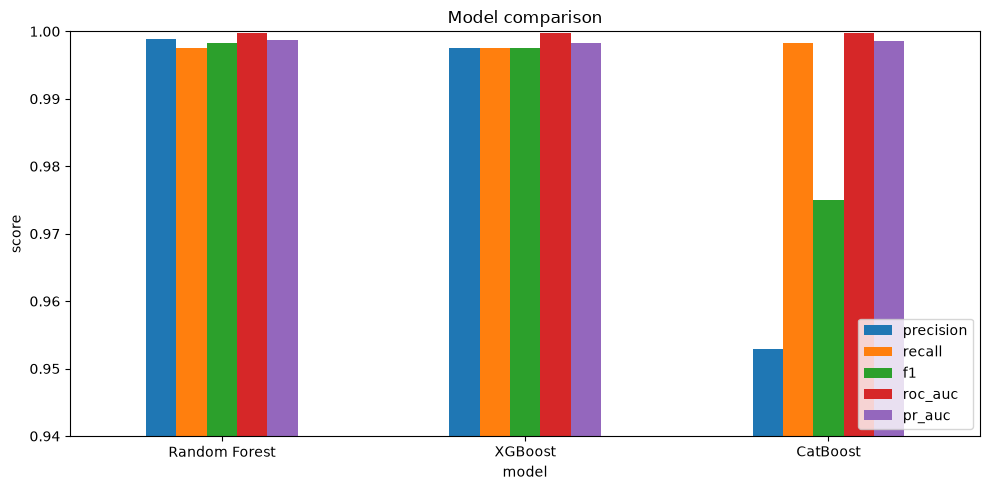

In [25]:
import matplotlib.pyplot as plt

comparison.plot(kind="bar", figsize=(10, 5), ylim=(0.94, 1.0))
plt.title("Model comparison")
plt.ylabel("score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [26]:
X_train.columns

Index(['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'errorBalanceOrig', 'errorBalanceDest', 'hour', 'day',
       'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT',
       'type_TRANSFER'],
      dtype='object')

In [27]:
len(X_train.columns)

14